# Notebook 7 — SOLUTION

## Short version

**The neurons do not encode the condition.** Firing here is
`baseline + loading * arousal + noise`, with no condition term at all. What
happened is that, in this dataset, **arousal was a bit higher on A trials than B
trials** -- and since every neuron in a session shares that arousal, every neuron
shows A > B. The 600 neurons are **not 600 independent observations**: neurons
within a session are strongly correlated, so they mostly re-report the same
handful of session-level arousal fluctuations. The correct unit of replication is
the session (n = 6), not the neuron (n = 600), and at that level the effect is
not significant. Regressing out arousal removes it entirely.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42


In [2]:
d = np.load('data/data.npz')
activity = d['activity']        # (sessions, neurons, trials) firing rate
condition = d['condition']      # (sessions, trials)  +1 = A, -1 = B
arousal = d['arousal']          # (sessions, trials)  arousal per trial
n_sessions, n_neurons, n_trials = activity.shape
print(f'{n_sessions} sessions x {n_neurons} neurons = {n_sessions*n_neurons} neurons total')


6 sessions x 100 neurons = 600 neurons total


In [3]:
A = activity[:, :, condition[0] == 1].mean(2)      # (sessions, neurons)
B = activity[:, :, condition[0] == -1].mean(2)
AmB = A - B                                         # (sessions, neurons)
t, p = stats.ttest_1samp(AmB.ravel(), 0)
print(f'naive test across {AmB.size} neurons: p = {p:.1e}')


naive test across 600 neurons: p = 4.3e-13


## Evidence 1 — The 600 "observations" are really 6 clusters

Neurons within a session share the same arousal signal, so their A-B differences
are nearly identical -- the population is not 600 independent points, it is 6
tight clusters (one per session). A few correlated sessions are masquerading as
hundreds of independent measurements.


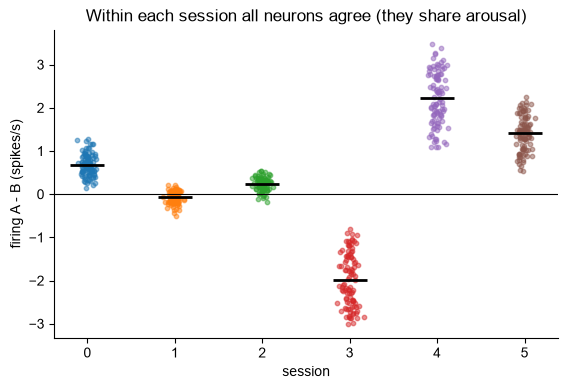

mean within-session pairwise neuron correlation: 0.54 (independent neurons would be ~0)


In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for s in range(n_sessions):
    jitter = np.random.default_rng(s).normal(s, 0.05, n_neurons)
    ax.scatter(jitter, AmB[s], s=10, alpha=0.5)
    ax.plot(s, AmB[s].mean(), 'k_', ms=25, mew=2)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('session'); ax.set_ylabel('firing A - B (spikes/s)')
ax.set_title('Within each session all neurons agree (they share arousal)')
plt.show()

# mean pairwise correlation of neurons' trial-by-trial activity within a session
rs = [np.corrcoef(activity[s])[np.triu_indices(n_neurons, 1)].mean() for s in range(n_sessions)]
print(f'mean within-session pairwise neuron correlation: {np.mean(rs):.2f} '
      f'(independent neurons would be ~0)')


## Evidence 2 — Use the right unit of replication: the session

Average A-B within each session, then test across the 6 sessions. Now the huge
session-to-session variability is visible, and the effect is not significant --
because there really are only ~6 independent measurements, not 600.


In [5]:
session_means = AmB.mean(1)               # one number per session
t_s, p_s = stats.ttest_1samp(session_means, 0)
print('per-session mean A-B:', np.round(session_means, 2))
print(f'test across n = {n_sessions} sessions: t = {t_s:.2f}, p = {p_s:.2f}')
print(f'(naive across {AmB.size} neurons was p = {p:.1e})')


per-session mean A-B: [ 0.68 -0.07  0.24 -1.98  2.22  1.41]
test across n = 6 sessions: t = 0.71, p = 0.51
(naive across 600 neurons was p = 4.3e-13)


## Evidence 3 — It's arousal: regress it out

Because firing tracks arousal and arousal differed between conditions, the "A-B"
effect is a confound. Regress each neuron's firing on arousal and test the
*residual* condition difference: it vanishes.


In [6]:
resid_AmB = np.zeros((n_sessions, n_neurons))
for s in range(n_sessions):
    a = arousal[s]; cond = condition[s]
    Xd = np.vstack([np.ones_like(a), a]).T           # design: intercept + arousal
    coef, *_ = np.linalg.lstsq(Xd, activity[s].T, rcond=None)   # fit every neuron at once
    resid = activity[s].T - Xd @ coef                # remove the arousal-explained part
    resid_AmB[s] = resid[cond == 1].mean(0) - resid[cond == -1].mean(0)

t_r, p_r = stats.ttest_1samp(resid_AmB.ravel(), 0)
print(f'after regressing out arousal: mean residual A-B = {resid_AmB.mean():+.3f} spikes/s, '
      f'p = {p_r:.2f}')


after regressing out arousal: mean residual A-B = +0.002 spikes/s, p = 0.68


## Ground truth


In [7]:
gt = np.load('data/ground_truth.npz', allow_pickle=True)
print('per-session A-vs-B arousal gap:', np.round(gt['arousal_gap'], 2))
print('note:', str(gt['note']))


per-session A-vs-B arousal gap: [ 0.69 -0.02  0.09 -1.94  2.3   1.64]
note: no per-neuron condition coding; firing = baseline + loading*arousal + noise. A>B is a shared arousal confound, so neurons within a session are correlated.


## The lesson

- **p-values assume independent observations.** Neurons recorded together share
  brain state (arousal, movement, drift), so they are correlated -- counting each
  as an independent sample shrinks the p-value toward zero and hugely overstates
  the evidence (pseudo-replication).
- **The unit of analysis is the independent unit.** Here that is the session (or
  animal), n = 6, not the neuron, n = 600. Summarize within unit and test across
  units, or use a mixed-effects model with a per-session random effect.
- **A shared confound multiplies into "many" fake observations.** One arousal
  difference, common to all neurons, reappears 600 times and looks overwhelming.
  Measure candidate confounds and regress them out; check that effects survive at
  the level of independent units.
